In [ ]:
# Cell 1: Install open_clip
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


In [ ]:
# Cell 2: Imports and Paths
import os
import numpy as np
import pandas as pd
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip

from google.colab import drive
drive.mount('/content/drive')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths (Reused from your code)
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"

val_df = pd.read_csv(base_path + "/val_split.csv") # We use validation/test set for Zero-Shot

Mounted at /content/drive
Using device: cuda


In [ ]:
# Cell 3: Load BioMedCLIP Model, Tokenizer, and Transforms
print("Loading BioMedCLIP model.")

# BioMedCLIP uses a ViT base patch 16 vision encoder and PubMedBERT text encoder
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'

# Load model, standard training transform (not needed here), and preprocessing transform
model, _, preprocess = open_clip.create_model_and_transforms(model_name)
model = model.to(device)
model.eval() # Set to evaluation mode! No training happens in zero-shot.

# Load the tokenizer specific to BioMedCLIP
tokenizer = open_clip.get_tokenizer(model_name)

print("BioMedCLIP loaded successfully!")

Loading BioMedCLIP model.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioMedCLIP loaded successfully!


In [ ]:
# Cell 4: Define Text Prompts
def get_text_prompts(plane_name):

    # Class 0: Negative (No Tear)
    prompt_healthy = f"A {plane_name} plane magnetic resonance imaging slice of a normal human knee with an intact anterior cruciate ligament."

    # Class 1: Positive (ACL Tear)
    prompt_tear = f"A {plane_name} plane magnetic resonance imaging slice of a human knee showing an anterior cruciate ligament tear."

    prompts = [prompt_healthy, prompt_tear]

    # Tokenize the text so the model can process it
    tokenized_prompts = tokenizer(prompts).to(device)

    return prompts, tokenized_prompts

# Let's test it to see what it looks like
test_prompts, _ = get_text_prompts("sagittal")
print("Prompt 0 (Healthy):", test_prompts[0])
print("Prompt 1 (Tear):   ", test_prompts[1])

Prompt 0 (Healthy): A sagittal plane magnetic resonance imaging slice of a normal human knee with an intact anterior cruciate ligament.
Prompt 1 (Tear):    A sagittal plane magnetic resonance imaging slice of a human knee showing an anterior cruciate ligament tear.


In [ ]:
# Cell 5: Dataset adaptation
def fix_slices(volume, target_slices=20):

    slices = volume.shape[0]
    if slices == target_slices: return volume
    if slices > target_slices:
        start = (slices - target_slices) // 2
        return volume[start:start + target_slices]
    else:
        pad = target_slices - slices
        return np.pad(volume, ((pad//2, pad - pad//2), (0, 0), (0, 0)), mode="constant")

class BioMedCLIP_MRNetDataset(Dataset):
    def __init__(self, df, plane_dir, preprocess_fn):
        self.df = df
        self.plane_dir = plane_dir
        self.preprocess = preprocess_fn # BioMedCLIP's image transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        # Load and fix slices
        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))
        vol = fix_slices(vol)

        processed_slices = []
        for i in range(vol.shape[0]):
            # BioMedCLIP expects PIL Images or numpy arrays shaped for PIL
            img = cv2.resize(vol[i], (224, 224))
            img = np.stack((img,)*3, axis=-1).astype(np.uint8)

            from PIL import Image
            img_pil = Image.fromarray(img)

            # Apply BioMedCLIP preprocessing (resizes, normalizes properly)
            img_tensor = self.preprocess(img_pil)
            processed_slices.append(img_tensor)

        # Return a tensor of shape [20, 3, 224, 224] (acting as a batch of 20 images)
        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.float32)


 STARTING ZERO-SHOT EVALUATION: AXIAL
Results for AXIAL plane:
  Accuracy: 40.80% | AUC: 0.5241
  Predicted Tears: 80 | Actual Tears: 26
------------------------------------------------------------


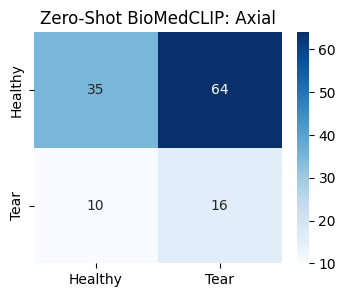


 STARTING ZERO-SHOT EVALUATION: CORONAL
Results for CORONAL plane:
  Accuracy: 33.60% | AUC: 0.4973
  Predicted Tears: 95 | Actual Tears: 26
------------------------------------------------------------


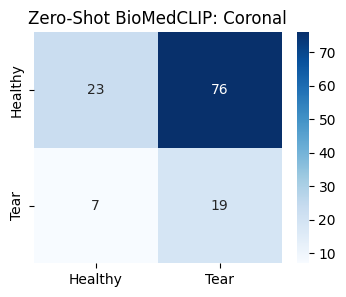


 STARTING ZERO-SHOT EVALUATION: SAGITTAL
Results for SAGITTAL plane:
  Accuracy: 20.80% | AUC: 0.5237
  Predicted Tears: 125 | Actual Tears: 26
------------------------------------------------------------


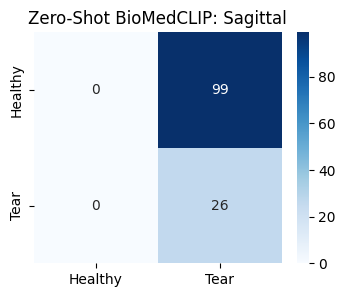

In [ ]:
# Cell 6: Zero-Shot Inference Logic
def evaluate_zero_shot(planes_to_test):

    for plane_name, plane_dir in planes_to_test:
        print(f"\n" + "="*60 + f"\n STARTING ZERO-SHOT EVALUATION: {plane_name.upper()}\n" + "="*60)

        # 1. Get Tokenized Text Prompts for this specific plane
        prompts_text, tokenized_prompts = get_text_prompts(plane_name)

        # 2. Extract Text Features (Embeddings) using the Text Encoder
        with torch.no_grad():
            text_features = model.encode_text(tokenized_prompts)
            # Normalize text features (standard practice for CLIP models)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # 3. Setup DataLoader
        val_ds = BioMedCLIP_MRNetDataset(val_df, plane_dir, preprocess)
        # Batch size 1 because 1 patient = 20 slices (which acts as our batch for the model)
        val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

        y_true, y_probs = [], []
        v_correct, v_pos_preds, v_actual_pos = 0, 0, 0

        # 4. Loop through patients
        with torch.no_grad():
            for imgs, lbl in val_loader:
                # imgs shape: [1, 20, 3, 224, 224]. Squeeze to [20, 3, 224, 224]
                imgs = imgs.squeeze(0).to(device)
                lbl = lbl.item()

                # Extract Image Features (Embeddings) for all 20 slices at once
                image_features = model.encode_image(imgs)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

                # Calculate Cosine Similarity (Logits) between 20 images and 2 texts
                # logit_scale is a learnable temperature parameter inside CLIP
                logit_scale = model.logit_scale.exp()
                logits_per_image = logit_scale * image_features @ text_features.t()

                # Convert logits to probabilities using Softmax
                probs = logits_per_image.softmax(dim=-1) # Shape: [20, 2]

                # Extract the probability of Class 1 (Tear) for all 20 slices
                prob_tear_per_slice = probs[:, 1]

                # AGGREGATION: How do we decide for the whole patient?
                # We take the Maximum probability across all 20 slices.
                # If even one slice strongly shows a tear, we classify the patient as having a tear.
                patient_prob_tear = torch.max(prob_tear_per_slice).item()

                y_true.append(lbl)
                y_probs.append(patient_prob_tear)

                # Stats calculation
                pred = 1 if patient_prob_tear > 0.5 else 0
                if pred == 1: v_pos_preds += 1
                if lbl == 1: v_actual_pos += 1
                if pred == lbl: v_correct += 1

        # 5. Calculate Metrics
        auc = roc_auc_score(y_true, y_probs) if len(set(y_true)) > 1 else 0.5
        acc = accuracy_score(y_true, [1 if p > 0.5 else 0 for p in y_probs])

        print(f"Results for {plane_name.upper()} plane:")
        print(f"  Accuracy: {acc*100:.2f}% | AUC: {auc:.4f}")
        print(f"  Predicted Tears: {v_pos_preds} | Actual Tears: {v_actual_pos}")
        print("-" * 60)

        # Display Confusion Matrix
        cm = confusion_matrix(y_true, [1 if p > 0.5 else 0 for p in y_probs])
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
        plt.title(f"Zero-Shot BioMedCLIP: {plane_name.capitalize()}")
        plt.show()

# Execution
target_planes = [("axial", axial_dir), ("coronal", coronal_dir), ("sagittal", sagittal_dir)]
evaluate_zero_shot(target_planes)